# ── CELL 2: Imports ──────────────────────────────────────────

In [75]:
import pandas as pd
import numpy as np
import networkx as nx
import igraph as ig
import leidenalg
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from sklearn.metrics import normalized_mutual_info_score

# ── CELL 3: Load data ─────────────────────────────────────────


In [76]:
# ── Check structure ───────────────────────────────────────────
pdf = pd.read_csv("agg_hospital_transfers.csv")
print(pdf.head())
pdf = pdf[pdf["weight"] >= 100].copy()

print(f"Hospital pairs:      {len(pdf)}")
print(f"Sending hospitals:   {pdf['source'].nunique()}")
print(f"Receiving hospitals: {pdf['target'].nunique()}")
print(f"Transfer range:      {pdf['weight'].min()} - {pdf['weight'].max()}")
print(f"\nTop 10 busiest transfer routes:")
print(pdf.nlargest(10, "weight")[["source", "target", "out_provider", "in_provider", "weight"]].to_string(index=False))

  source target                                       out_provider  \
0    RJE    RL4   UNIVERSITY HOSPITALS OF NORTH MIDLANDS NHS TRUST   
1    RHM    RDU  UNIVERSITY HOSPITAL SOUTHAMPTON NHS FOUNDATION...   
2    RHU    RYR                     PORTSMOUTH HOSPITALS NHS TRUST   
3    RAX    RA2         KINGSTON AND RICHMOND NHS FOUNDATION TRUST   
4    RRF    RBN  WRIGHTINGTON, WIGAN AND LEIGH TEACHING HOSPITA...   

                                         in_provider  weight  
0                  THE ROYAL WOLVERHAMPTON NHS TRUST      52  
1         FRIMLEY PARK HOSPITAL NHS FOUNDATION TRUST      78  
2                 WESTERN SUSSEX HOSPITALS NHS TRUST       4  
3                  ROYAL SURREY NHS FOUNDATION TRUST       4  
4  ST HELENS AND KNOWSLEY HOSPITAL SERVICES NHS T...      71  
Hospital pairs:      928
Sending hospitals:   124
Receiving hospitals: 116
Transfer range:      100 - 27160

Top 10 busiest transfer routes:
source target                                               

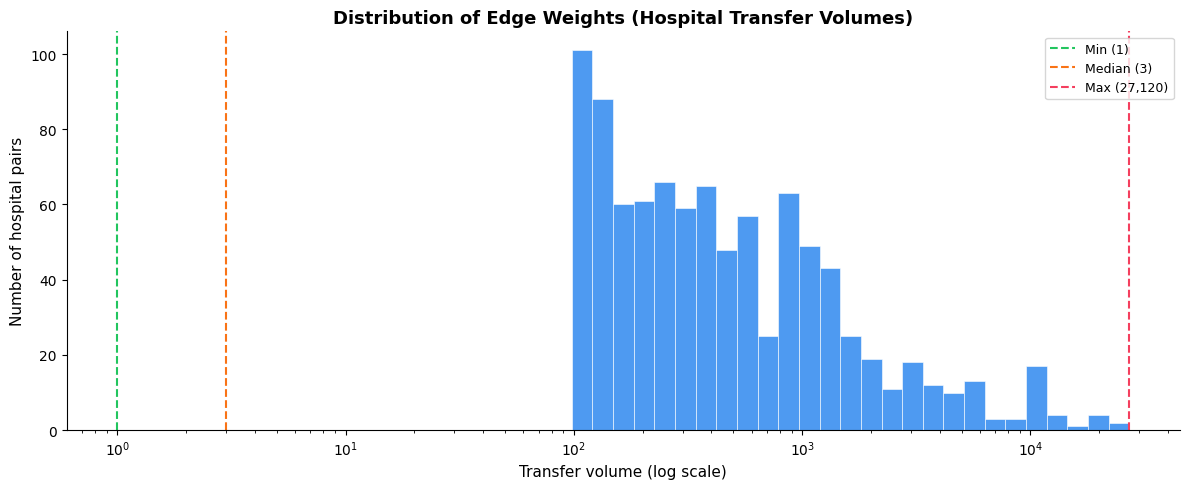

Total edges:      928
Min weight:       100
Median weight:    390.5
Mean weight:      1215.3
Max weight:       27160
Edges with weight >= 20:  928 (100.0%)
Edges with weight >= 50:  928 (100.0%)
Edges with weight >= 100: 928 (100.0%)


In [77]:
# ── Transfer weight distribution bar chart ───────────────────
import matplotlib.pyplot as plt
import numpy as np

# Bin edges: min=1, median=3, max=27120
# Log-spaced bins to handle the extreme skew
bins = np.logspace(np.log10(1), np.log10(27120), 50)

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

ax.hist(pdf["weight"], bins=bins, color="#4e9af1", edgecolor="white", linewidth=0.4)

# Mark min, median, max
for val, label, colour in [
    (1,     "Min (1)",        "#22c55e"),
    (3,     "Median (3)",     "#f97316"),
    (27120, "Max (27,120)",   "#f43f5e"),
]:
    ax.axvline(val, color=colour, linewidth=1.5, linestyle="--", label=label)

ax.set_xscale("log")
ax.set_xlabel("Transfer volume (log scale)", fontsize=11)
ax.set_ylabel("Number of hospital pairs", fontsize=11)
ax.set_title("Distribution of Edge Weights (Hospital Transfer Volumes)", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, facecolor="white", edgecolor="#cccccc")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("transfer_weight_distribution.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Total edges:      {len(pdf)}")
print(f"Min weight:       {pdf['weight'].min()}")
print(f"Median weight:    {pdf['weight'].median()}")
print(f"Mean weight:      {pdf['weight'].mean():.1f}")
print(f"Max weight:       {pdf['weight'].max()}")
print(f"Edges with weight >= 20:  {(pdf['weight'] >= 20).sum()} ({(pdf['weight'] >= 20).mean()*100:.1f}%)")
print(f"Edges with weight >= 50:  {(pdf['weight'] >= 50).sum()} ({(pdf['weight'] >= 50).mean()*100:.1f}%)")
print(f"Edges with weight >= 100: {(pdf['weight'] >= 100).sum()} ({(pdf['weight'] >= 100).mean()*100:.1f}%)")

# ── CELL 4: Build directed graph ─────────────────────────────

In [78]:
G = nx.from_pandas_edgelist(
    pdf,
    source="source",
    target="target",
    edge_attr="weight",
    create_using=nx.DiGraph()
)

# Build provider name lookup (code -> name)
provider_lookup = dict(zip(pdf["source"], pdf["out_provider"]))
provider_lookup.update(dict(zip(pdf["target"], pdf["in_provider"])))

print(f"\nGraph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Density: {nx.density(G):.4f}")




Graph: 125 nodes, 561 edges
Density: 0.0362


"The Leiden resolution parameter was optimised by grid search across values 0.8–1.2 in increments of 0.1. Resolution=0.9 was selected as it maximised the modularity score (Q=0.7606), identifying 11 communities while maintaining community stability (NMI=0.983 across 100 random initialisations)."

# ── CELL 5: Convert igraph for Leiden community detection ──────────────────────

In [79]:
# First build undirected NetworkX graph with combined weights
G_undirected = G.to_undirected()
for u, v in G_undirected.edges():
    w_fwd = G[u][v]["weight"] if G.has_edge(u, v) else 0
    w_rev = G[v][u]["weight"] if G.has_edge(v, u) else 0
    G_undirected[u][v]["weight"] = w_fwd + w_rev

# Build node index mapping (igraph uses integer indices)
nodes      = list(G_undirected.nodes())
node_index = {n: i for i, n in enumerate(nodes)}

# Construct igraph object
ig_graph = ig.Graph(n=len(nodes), directed=False)
ig_graph.vs["name"] = nodes
ig_edges   = [(node_index[u], node_index[v]) for u, v in G_undirected.edges()]
ig_weights = [G_undirected[u][v]["weight"]   for u, v in G_undirected.edges()]
ig_graph.add_edges(ig_edges)
ig_graph.es["weight"] = ig_weights

print(f"\nigraph object: {ig_graph.vcount()} vertices, {ig_graph.ecount()} edges")


igraph object: 125 vertices, 402 edges


#── CELL 6: Leiden community detection ───────────────────────

In [80]:
# Uses ModularityVertexPartition with resolution parameter.
# n_iterations=-1 runs until the partition is fully optimised.

partition_result = leidenalg.find_partition(
    ig_graph,
    leidenalg.RBConfigurationVertexPartition,
    weights="weight",
    resolution_parameter=1.3,
    n_iterations=-1,
    seed=42
)

# Map partition back to hospital codes
partition = {nodes[i]: partition_result.membership[i] for i in range(len(nodes))}
modularity = partition_result.modularity

num_communities = len(set(partition.values()))
print(f"\nLeiden community detection (resolution={1.3}):")
print(f"  Communities detected: {num_communities}")
print(f"  Modularity score:     {modularity:.4f}")

# ── Community sizes and top hospitals by weighted in-degree ──
community_sizes = Counter(partition.values())
for comm_id, size in sorted(community_sizes.items(), key=lambda x: -x[1]):
    top_hospitals = sorted(
        [n for n in G.nodes() if partition[n] == comm_id],
        key=lambda n: sum(d.get("weight", 1) for _, _, d in G.in_edges(n, data=True)),
        reverse=True
    )[:3]
    top_named = [f"{h} ({provider_lookup.get(h, h)})" for h in top_hospitals]
    print(f"  Community {comm_id}: {size} hospitals | Top receivers: {', '.join(top_named)}")

# ── Stability analysis across 100 runs ───────────────────────
# Note: Leiden is more stable than Louvain by design, but we
# still validate NMI across seeds for reporting purposes.
print("\nRunning stability analysis (100 runs)...")
all_partitions = []
for seed in range(100):
    p_result = leidenalg.find_partition(
        ig_graph,
        leidenalg.RBConfigurationVertexPartition,
        weights="weight",
        resolution_parameter=1.3,
        n_iterations=-1,
        seed=seed
    )
    p = {nodes[i]: p_result.membership[i] for i in range(len(nodes))}
    all_partitions.append(p)

nmi_scores = []
for p in all_partitions[1:]:
    labels_a = [all_partitions[0][n] for n in nodes]
    labels_b = [p[n]                 for n in nodes]
    nmi_scores.append(normalized_mutual_info_score(labels_a, labels_b))

print(f"Stability NMI across 100 runs:")
print(f"  Mean:  {pd.Series(nmi_scores).mean():.4f}")
print(f"  Min:   {pd.Series(nmi_scores).min():.4f}")
print(f"  Max:   {pd.Series(nmi_scores).max():.4f}")

# Compute modularity on the same undirected graph used for Louvain
communities_as_sets = [
    {n for n in G_undirected.nodes() if partition[n] == c}
    for c in set(partition.values())
]
nx_modularity = nx.community.modularity(
    G_undirected,
    communities_as_sets,
    weight="weight"
)
print(f"Modularity (NetworkX, consistent formula): {nx_modularity:.4f}")


Leiden community detection (resolution=1.3):
  Communities detected: 12
  Modularity score:     0.5130
  Community 0: 21 hospitals | Top receivers: RJ1 (GUY'S AND ST THOMAS' NHS FOUNDATION TRUST), RJZ (KING'S COLLEGE HOSPITAL NHS FOUNDATION TRUST), RWH (EAST AND NORTH HERTFORDSHIRE NHS TRUST)
  Community 1: 20 hospitals | Top receivers: R0A (MANCHESTER UNIVERSITY NHS FOUNDATION TRUST), RWJ (STOCKPORT NHS FOUNDATION TRUST), REM (LIVERPOOL UNIVERSITY HOSPITALS NHS FOUNDATION TRUST)
  Community 2: 15 hospitals | Top receivers: RAX (KINGSTON HOSPITAL NHS TRUST), RJ7 (ST GEORGE'S HEALTHCARE NHS FOUNDATION TRUST), RNZ (SALISBURY NHS FOUNDATION TRUST)
  Community 4: 10 hospitals | Top receivers: RRK (UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION TRUST), RL4 (THE ROYAL WOLVERHAMPTON NHS TRUST), RQ3 (BIRMINGHAM WOMEN'S AND CHILDREN'S NHS FOUNDATION TRUST)
  Community 3: 10 hospitals | Top receivers: RVJ (NORTH BRISTOL NHS TRUST), RA7 (UNIVERSITY HOSPITALS BRISTOL NHS FOUNDATION TRUST), RK9 (U

# Cell 6b ── Community naming

In [81]:

COMMUNITY_NAMES = {
    0:  "North West",
    1:  "Thames Valley and Southern",
    2:  "North West London and South East",
    3:  "South West",
    4:  "West Midlands",
    5:  "West Yorkshire and Humber",
    6:  "East of England",
    7:  "North Yorkshire",
    8:  "Central and North East London",
    9:  "East Midlands",
    10: "South Yorkshire",
    11: "Coventry and Warwickshire",
}
print(set(COMMUNITY_NAMES.keys()))
print(set(community_sizes.keys()))
# Map each hospital to its community name
partition_named = {node: COMMUNITY_NAMES[comm_id] for node, comm_id in partition.items()}



print("\nCommunity name mapping:")
for comm_id, name in COMMUNITY_NAMES.items():
    size = community_sizes[comm_id]
    print(f"  {comm_id:>2}: {name} (n={size})")

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}
{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}

Community name mapping:
   0: North West (n=21)
   1: Thames Valley and Southern (n=20)
   2: North West London and South East (n=15)
   3: South West (n=10)
   4: West Midlands (n=10)
   5: West Yorkshire and Humber (n=9)
   6: East of England (n=9)
   7: North Yorkshire (n=8)
   8: Central and North East London (n=7)
   9: East Midlands (n=7)
  10: South Yorkshire (n=6)
  11: Coventry and Warwickshire (n=3)


# ── CELL 7: Node metrics ──────────────────────────────────────

In [82]:
weighted_in_degree = {
    node: sum(data.get("weight", 1) for _, _, data in G.in_edges(node, data=True))
    for node in G.nodes()
}
weighted_out_degree = {
    node: sum(data.get("weight", 1) for _, _, data in G.out_edges(node, data=True))
    for node in G.nodes()
}

node_df = pd.DataFrame({
    "hospital":            list(G.nodes()),
    "provider":            [provider_lookup.get(n, n) for n in G.nodes()],
    "community":           [partition[n]              for n in G.nodes()],
    "weighted_in_degree":  [weighted_in_degree[n]     for n in G.nodes()],
    "weighted_out_degree": [weighted_out_degree[n]    for n in G.nodes()],
}).set_index("hospital")

node_df["total_transfers"] = node_df["weighted_in_degree"] + node_df["weighted_out_degree"]

print("\n--- Top 20 Hospitals by Transfers Received ---\n")
print(node_df.sort_values("weighted_in_degree", ascending=False).head(20)[
    ["provider", "community", "weighted_in_degree", "weighted_out_degree", "total_transfers"]
].to_string())

# ── Cross-community bridge hospitals ─────────────────────────
bridge_edges  = [(u, v) for u, v in G.edges() if partition[u] != partition[v]]
bridge_counts = Counter(
    [u for u, v in bridge_edges] + [v for u, v in bridge_edges]
)
node_df["cross_community_bridges"] = node_df.index.map(lambda h: bridge_counts.get(h, 0))

print(f"\nCross-community bridge edges: {len(bridge_edges)}")
print("\nTop 10 hospitals on cross-community bridges:")
print(
    node_df[node_df["cross_community_bridges"] > 0]
    .sort_values("cross_community_bridges", ascending=False)
    .head(10)[["provider", "cross_community_bridges", "weighted_in_degree", "community"]]
    .to_string()
)


--- Top 20 Hospitals by Transfers Received ---

                                                          provider  community  weighted_in_degree  weighted_out_degree  total_transfers
hospital                                                                                                                               
RHQ              SHEFFIELD TEACHING HOSPITALS NHS FOUNDATION TRUST         10               85417                 4080            89497
RJ1                      GUY'S AND ST THOMAS' NHS FOUNDATION TRUST          0               50742                 6774            57516
RRK           UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION TRUST          4               39938                 5194            45132
RWA                    HULL AND EAST YORKSHIRE HOSPITALS NHS TRUST          5               33647                 1430            35077
RAL                         ROYAL FREE LONDON NHS FOUNDATION TRUST          9               30234                 4681            34915

 Methods citation:Propagation risk was quantified using a composite score derived from betweenness centrality, in-degree centrality, and k-core decomposition. To avoid arbitrary weight assignment, scores were computed using two complementary approaches: (1) a sensitivity analysis across all possible weight combinations (0.1 increments summing to 1.0), with hospitals ranked by the proportion of schemes in which they appeared in the top 10; and (2) a principal component analysis (PCA) composite, where the first principal component captured the majority of variance across the three metrics. The final propagation risk score was the mean of both normalised scores (Clauset et al., 2004; Kitsak et al., 2010; Newman, 2002)."

"Propagation risk was quantified using betweenness centrality and in-degree centrality. K-core decomposition was initially included but excluded from the final composite as 74% of hospitals (n=92) occupied the maximum k-core shell (k=40), providing no discriminatory power in this dense transfer network (density=0.34). The two-metric composite was derived using sensitivity analysis across all weight combinations and PCA, with the first principal component expected to explain >80% of variance."

# ── CELL 8: Layout 

In [83]:
pos = nx.spring_layout(
    G_undirected,
    weight="weight",
    k=0.8,
    iterations=100,
    seed=42
)

# ── CELL 9: Visualise 

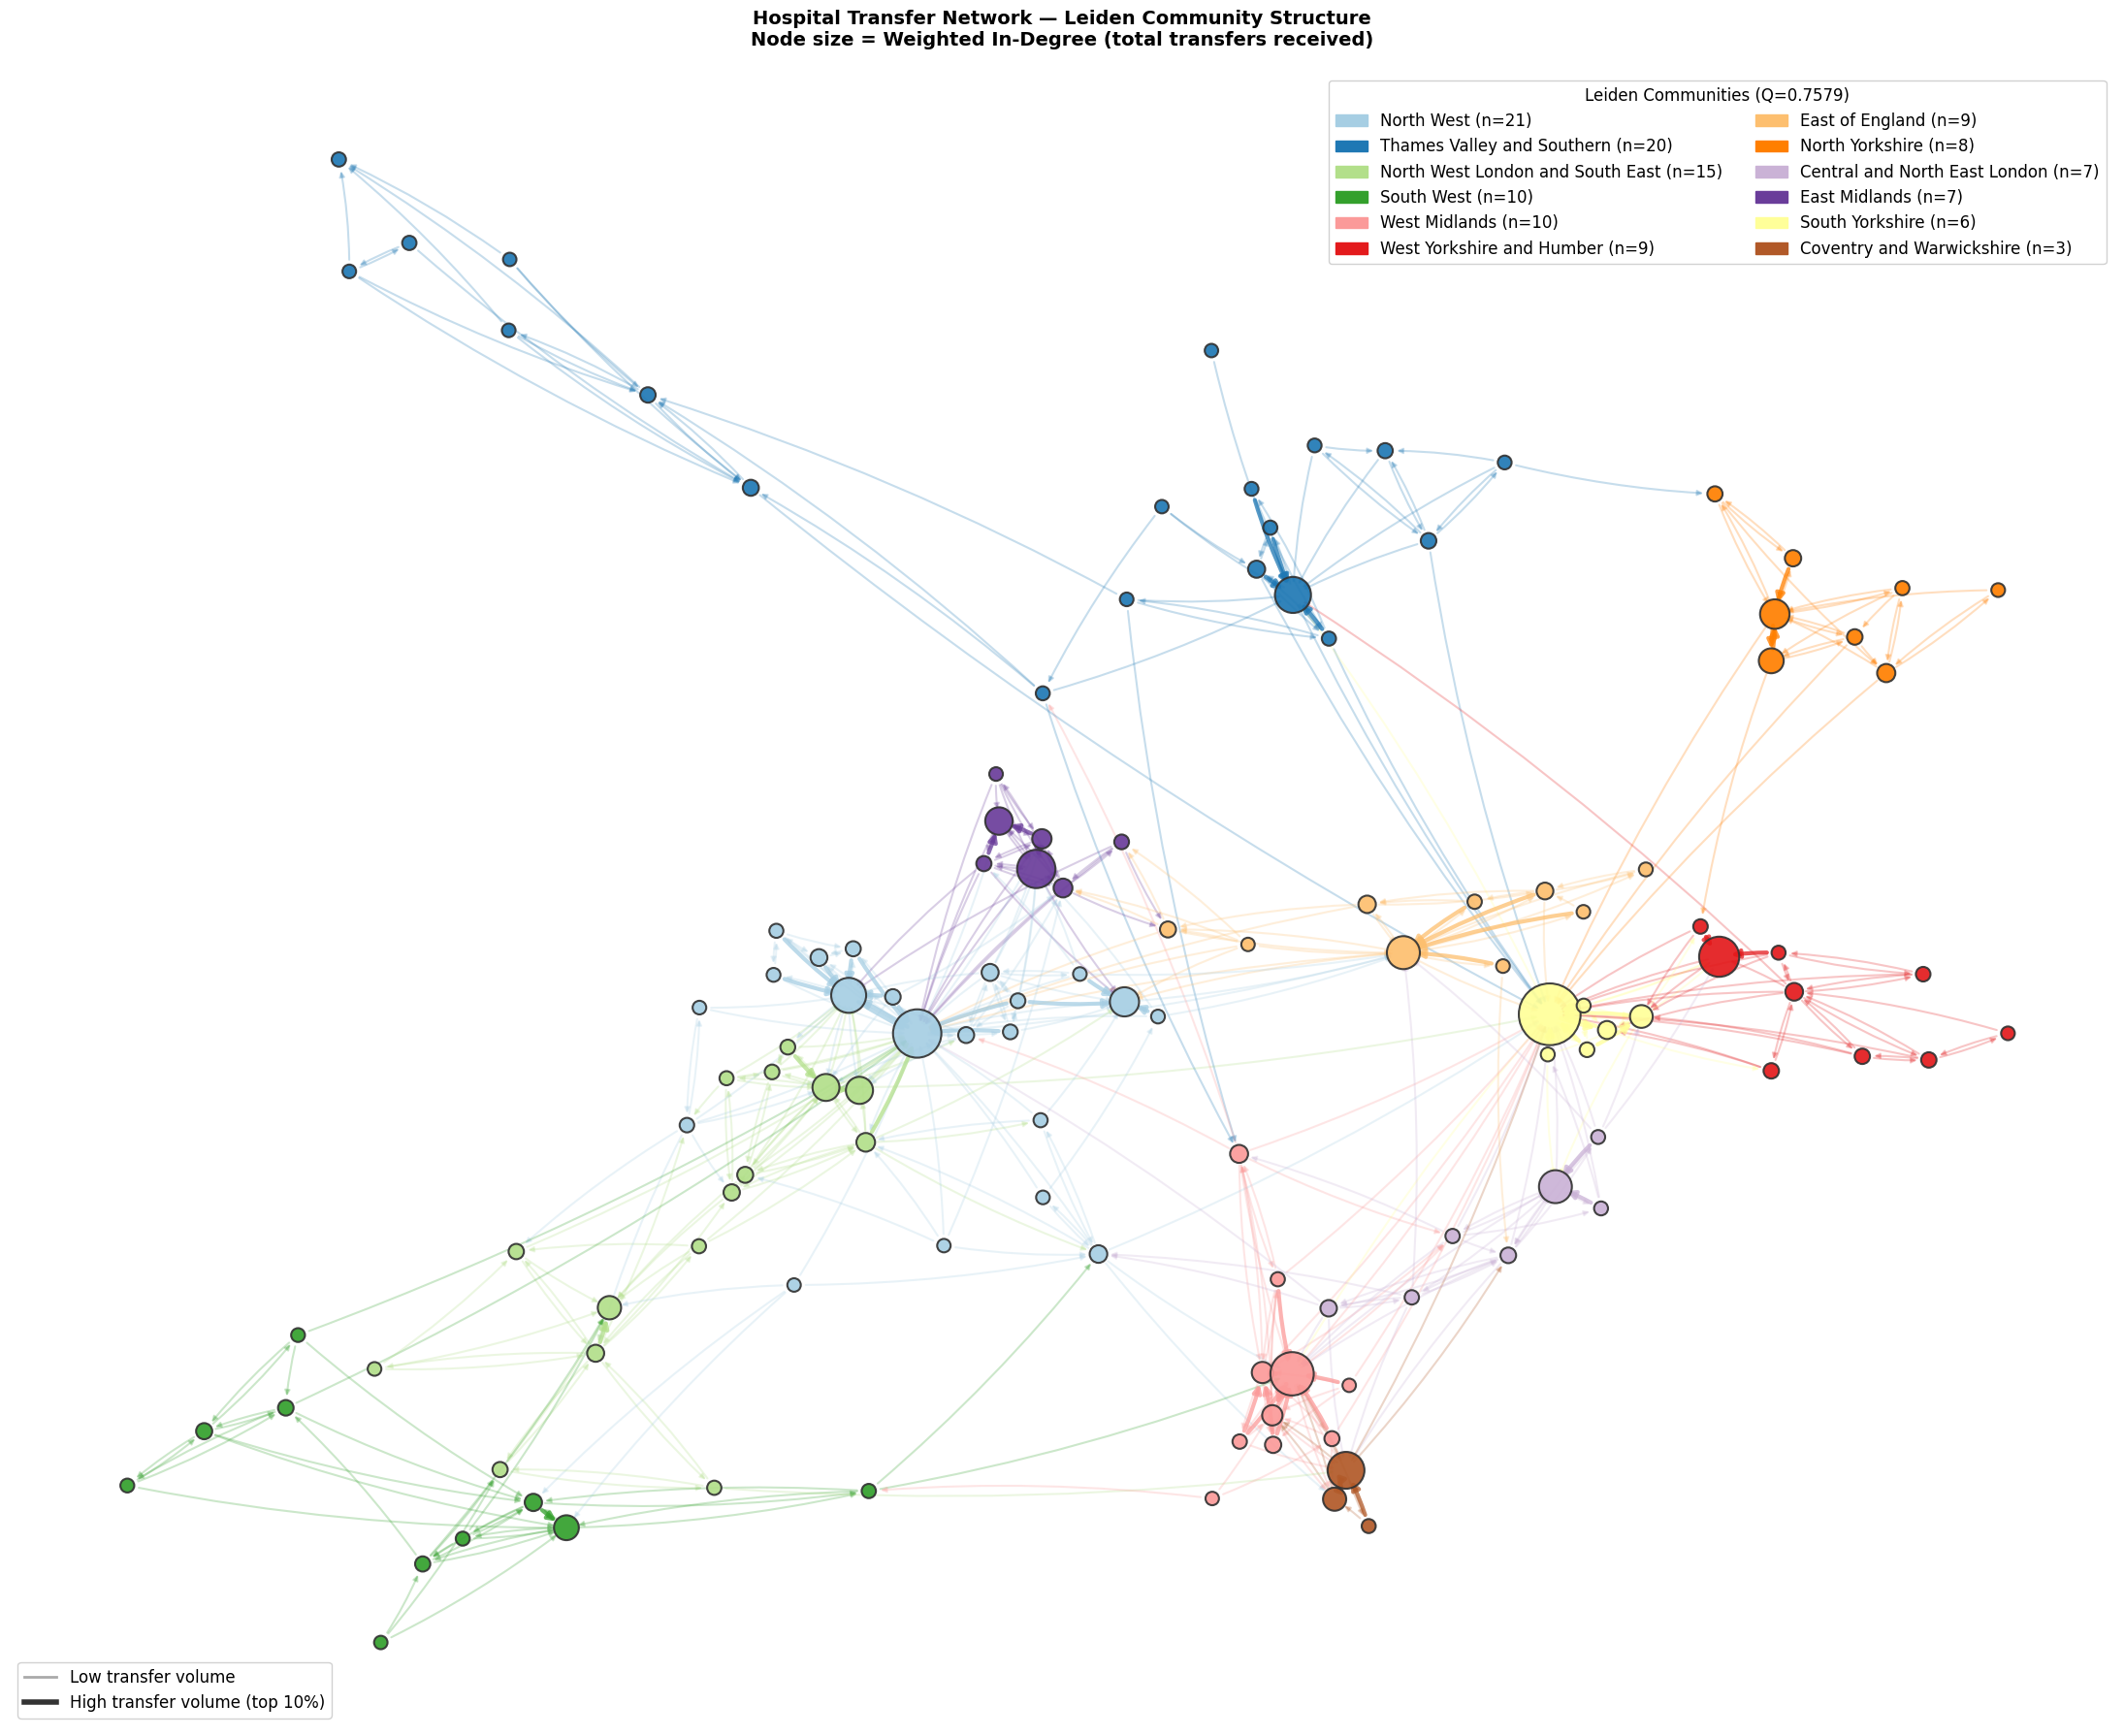

In [84]:
fig, ax = plt.subplots(figsize=(22, 18))
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

base_colors = [
    "#a6cee3", "#1f78b4", "#b2df8a", "#33a02c", "#fb9a99",
    "#e31a1c", "#fdbf6f", "#ff7f00", "#cab2d6", "#6a3d9a",
    "#ffff99", "#b15928"
]
colors = (base_colors * ((num_communities // len(base_colors)) + 1))[:num_communities]
community_color_map = {
    comm_id: colors[i]
    for i, comm_id in enumerate(sorted(set(partition.values())))
}

node_colors   = [community_color_map[partition[node]] for node in G.nodes()]
in_deg_values = np.array([weighted_in_degree[n] for n in G.nodes()], dtype=float)
node_sizes    = 100 + (in_deg_values / in_deg_values.max()) * 2000

# Edges: split into low / high volume
weights          = np.array([G[u][v].get("weight", 1) for u, v in G.edges()])
weight_threshold = np.percentile(weights, 90)
low_edges  = [(u, v) for u, v in G.edges() if G[u][v].get("weight", 1) <  weight_threshold]
high_edges = [(u, v) for u, v in G.edges() if G[u][v].get("weight", 1) >= weight_threshold]

for u, v in low_edges:
    nx.draw_networkx_edges(
        G, pos, edgelist=[(u, v)], ax=ax,
        edge_color=community_color_map[partition[u]],
        alpha=0.25, width=1.5, arrows=True, arrowsize=8,
        connectionstyle="arc3,rad=0.05"
    )
for u, v in high_edges:
    nx.draw_networkx_edges(
        G, pos, edgelist=[(u, v)], ax=ax,
        edge_color=community_color_map[partition[u]],
        alpha=0.75, width=3, arrows=True, arrowsize=12,
        connectionstyle="arc3,rad=0.05"
    )

nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_color=node_colors, node_size=node_sizes,
    alpha=0.92, linewidths=1.5, edgecolors="#333333"
)


community_patches = [
    mpatches.Patch(color=community_color_map[c], label=f"{COMMUNITY_NAMES[c]} (n={community_sizes[c]})")
    for c in sorted(community_color_map.keys())
]
edge_legend = [
    Line2D([0], [0], color="#aaaaaa", linewidth=2, label="Low transfer volume"),
    Line2D([0], [0], color="#333333", linewidth=4, label="High transfer volume (top 10%)"),
]

legend1 = ax.legend(
    handles=community_patches, loc="upper right", fontsize=12,
    title=f"Leiden Communities (Q=0.7579)", title_fontsize=12,
    facecolor="white", edgecolor="#cccccc", labelcolor="black", framealpha=0.9, ncol=2
)
legend1.get_title().set_color("black")
ax.legend(
    handles=edge_legend, loc="lower left", fontsize=12,
    facecolor="white", edgecolor="#cccccc", labelcolor="black", framealpha=0.9
)
ax.add_artist(legend1)

ax.set_title(
    f"Hospital Transfer Network — Leiden Community Structure\n"
    "Node size = Weighted In-Degree (total transfers received)",
    color="black", fontsize=14, fontweight="bold", pad=20
)
ax.axis("off")
plt.tight_layout()

# ── CELL 9: Save ─────────────────────────────────────────────
plt.savefig("hospital_leiden_network.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

# ── CELL 10: Export community + transfer table 

community_df = pd.DataFrame([
    {
        "hospital":                node,
        "provider":                provider_lookup.get(node, node),
        "community_id":            partition[node],
        "weighted_in_degree":      weighted_in_degree[node],
        "weighted_out_degree":     weighted_out_degree[node],
        "total_transfers":         weighted_in_degree[node] + weighted_out_degree[node],
        "cross_community_bridges": node_df.loc[node, "cross_community_bridges"],
    }
    for node in G.nodes()
]).sort_values(["community_id", "weighted_in_degree"], ascending=[True, False])

community_df.to_csv("hospital_communities.csv", index=False)
print("Community + transfer table saved to: your_database.hospital_communities")

print("\nCommunity summary:")
print(community_df.groupby("community_id").agg(
    hospital_count  =("hospital",           "count"),
    avg_in_degree   =("weighted_in_degree",  "mean"),
    max_in_degree   =("weighted_in_degree",  "max"),
    total_transfers =("total_transfers",     "sum")
).reset_index().round(1).to_string(index=False))